# Internship Scam Detection using Machine Learning
#### Module: Binary Classification

---

### Project Aim & Objective
The primary goal of this project is to build an end-to-end machine learning pipeline that automatically identifies and classifies fraudulent internship postings. This notebook serves as a practical, beginner-friendly guide to detecting these malicious postings using metadata analytics.

---

### Pipeline Architecture
1. **Exploratory Data Analysis (EDA)**
2. **Train-Test Separation**
3. **Data Imputation & Preprocessing**
4. **Model Training**
5. **Evaluation**

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Basic data exploration

In [ ]:
df = pd.read_csv("internship_scam_data.csv")
df.head()

,posting_date,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,...,recruiter_experience_years,recruiter_email_type,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
0,2026-09-10,ML Engineer,Internship,Remote,Marketing,Berlin,"Russell, Medina and Evans",Startup,23.0,1,...,0.3,Free,1,17.6,1,12,28,48.4,51.8,1
1,2020-05-10,UI/UX Designer,Contract,Onsite,Marketing,Bangalore,Hays-White,Startup,12.0,0,...,5.1,Free,1,30.2,1,9,27,47.6,75.3,1
2,2021-07-18,UI/UX Designer,Internship,Hybrid,Gaming,Toronto,"Obrien, Gonzalez and Harris",Small,10.0,1,...,6.0,Free,1,12.5,0,26,18,98.8,0.0,0
3,2021-02-04,UI/UX Designer,Part-Time,Remote,AI,Berlin,"Martinez, Odonnell and Davidson",Enterprise,33.0,1,...,3.8,Corporate,0,24.6,1,20,0,72.2,11.0,0
4,2020-12-31,AI Research Intern,Internship,Onsite,EdTech,Toronto,Garcia-Owens,Small,14.0,0,...,7.0,Free,1,30.3,0,16,50,34.4,56.0,1


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   posting_date                   1000000 non-null  object 
 1   internship_title               1000000 non-null  object 
 2   employment_type                1000000 non-null  object 
 3   work_mode                      1000000 non-null  object 
 4   industry                       1000000 non-null  object 
 5   location                       1000000 non-null  object 
 6   company_name                   1000000 non-null  object 
 7   company_size                   1000000 non-null  object 
 8   company_age                    990000 non-null   float64
 9   linkedin_presence              1000000 non-null  int64  
 10  website_available              1000000 non-null  int64  
 11  domain_age_months              1000000 non-null  int64  
 12  verification_st

Null columns: `stipend`, `company_age` and `trust_signal_score` | all are numerical columns 
#### Strategy for replacing NULLS:
1. `stipend` : value 0
2. `company_age` : median
3. `trust_signal_score` : median

## EDA

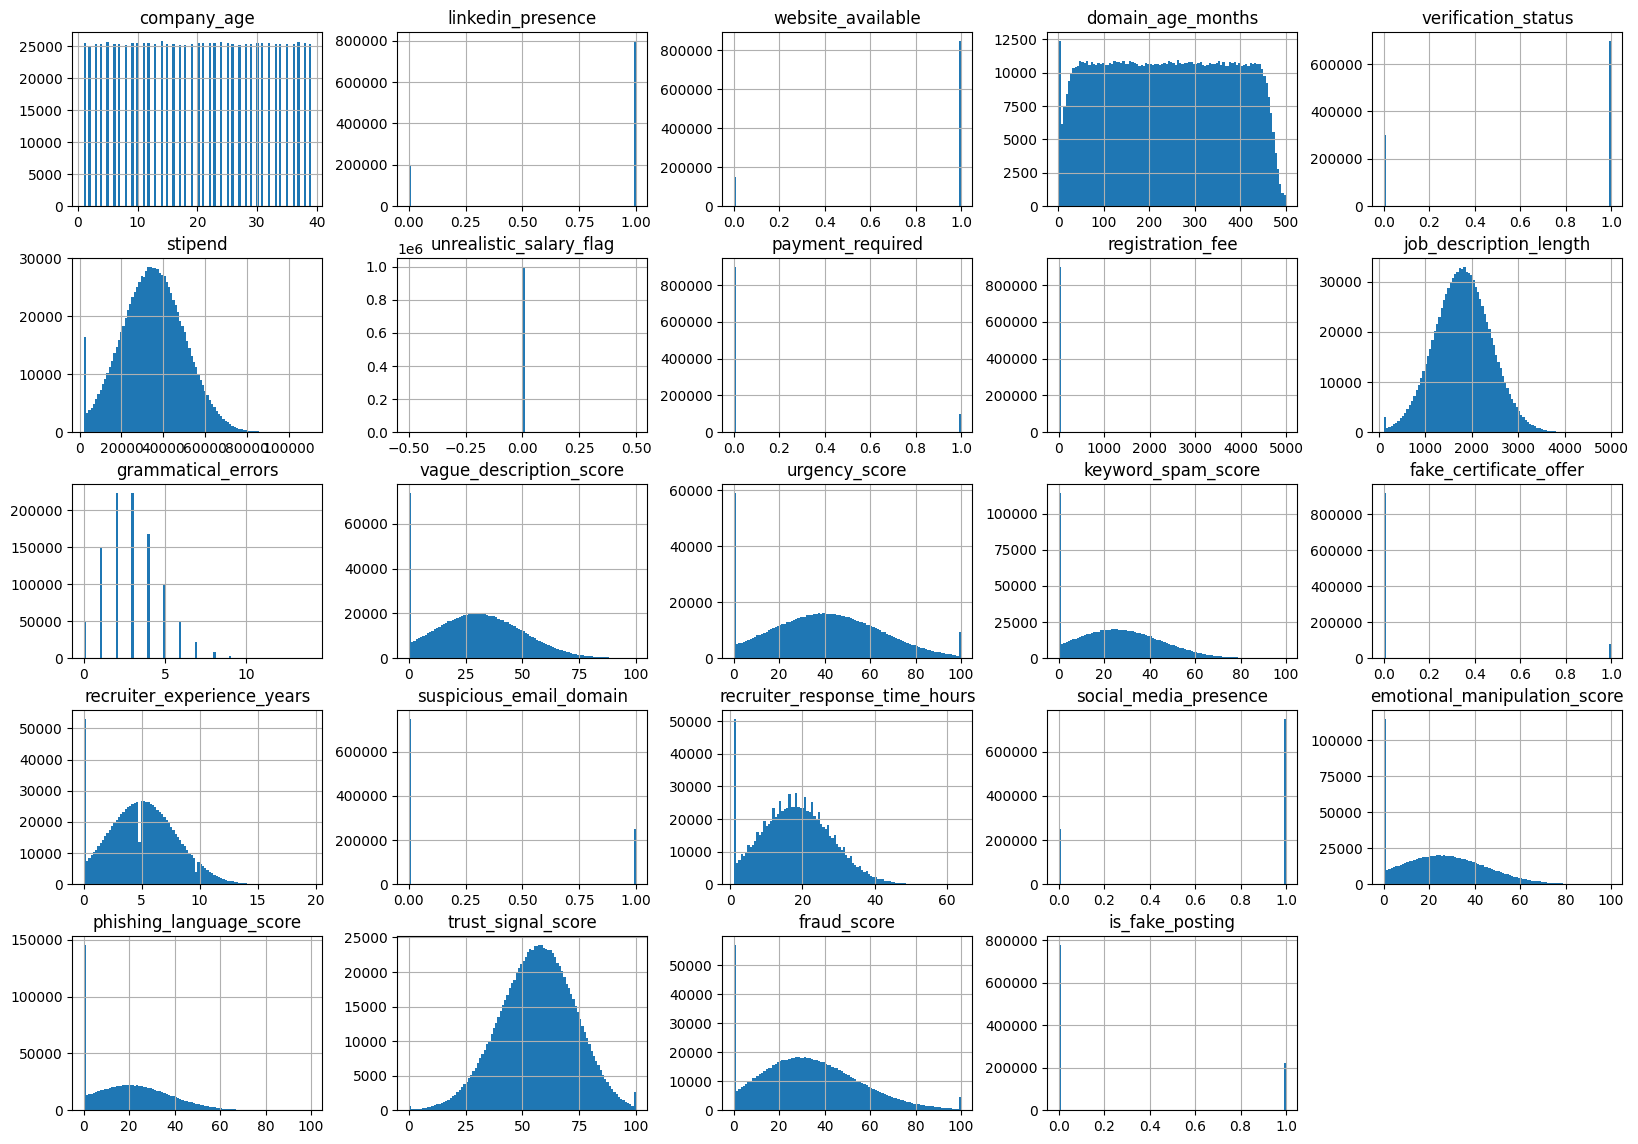

In [67]:
df.hist(bins=100, figsize=(20,14))
plt.show()

---
### correlation between all numeric columns and `is_fake_posting`

In [68]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix["is_fake_posting"].sort_values(ascending=False)

is_fake_posting                  1.000000
fraud_score                      0.763767
payment_required                 0.374175
registration_fee                 0.321503
phishing_language_score          0.278532
vague_description_score          0.243059
suspicious_email_domain          0.219823
fake_certificate_offer           0.206038
urgency_score                    0.141569
grammatical_errors               0.110640
keyword_spam_score               0.110176
recruiter_response_time_hours    0.000430
emotional_manipulation_score    -0.000384
job_description_length          -0.000529
stipend                         -0.000765
recruiter_experience_years      -0.001493
social_media_presence           -0.001540
domain_age_months               -0.029391
company_age                     -0.029751
verification_status             -0.041771
website_available               -0.189424
linkedin_presence               -0.206890
trust_signal_score              -0.386458
unrealistic_salary_flag           

In [69]:
df['unrealistic_salary_flag'].value_counts()

unrealistic_salary_flag
0    1000000
Name: count, dtype: int64

### Drop not-so-useful columns
1. The `unrealistic_salary_flag` is populated with all 0s. Therefore, it is not of much use and can be safely dropped.
2. High Cardinality Fields: `posting_date`, `company_name`, `internship_title`, `location`
3. We will convert 


In [70]:
df.drop(["unrealistic_salary_flag", 'posting_date', 'company_name', 'internship_title', 'location', 'fraud_score'], axis=1, inplace=True)

In [71]:
df["recruiter_email_type"].value_counts()

recruiter_email_type
Corporate    749433
Free         250567
Name: count, dtype: int64

### Train Test Split

In [72]:
# split into X and y
X = df.drop(columns=['is_fake_posting'])
y = df['is_fake_posting']

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

segregating numerical and categorical columns

In [74]:
# Automatically collect all other clean numeric features
all_numeric = X.select_dtypes(include=[np.number]).columns.tolist()
clean_numeric_cols = [c for c in all_numeric if c not in (['stipend'] + ['company_age'] + ['trust_signal_score'])]

# Automatically collect categorical columns for encoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

### Automated ColumnTransformer Pipelines

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Build individual step pipelines
stipend_pipeline = Pipeline([
    ('imputer_zero', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

age_pipeline = Pipeline([
    ('imputer_median', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

trust_pipeline = Pipeline([
    ('imputer_trust', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_clean_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [76]:
# Assemble everything into a single ColumnTransformer layout
preprocessing_pipeline = ColumnTransformer(transformers=[
    ('stipend_path', stipend_pipeline, ['stipend']),
    ('age_path', age_pipeline, ['company_age']),
    ('trust_path', trust_pipeline, ['trust_signal_score']),
    ('num_clean_path', numeric_clean_pipeline, clean_numeric_cols),
    ('cat_path', categorical_pipeline, categorical_cols)
])

### Baseline model: DecisionTreeClassifier

In [77]:
# Fit and transform the training split; transform the testing split cleanly
X_train_prepared = preprocessing_pipeline.fit_transform(X_train)
X_test_prepared = preprocessing_pipeline.transform(X_test)

### GridSearchCV Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Initialize a base Decision Tree
base_tree = DecisionTreeClassifier(random_state=42)

# 2. Define the exact parameter grid you want to test
# We will test depths of 5, 10, and 15 to see which prevents overfitting best
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

# 3. Set up the Grid Search engine
grid_search = GridSearchCV(
    estimator=base_tree, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1_macro',
    verbose=1
)

print("Starting Grid Search across combinations...")
# 4. Run the search on your clean, prepared training data
grid_search.fit(X_train_prepared, y_train)

# 5. Print the mathematically optimal parameters discovered
print("\n--- Optimal Hyperparameters Found ---")
print(grid_search.best_params_)

# 6. Extract the best optimized model directly
best_tree_model = grid_search.best_estimator_

# 7. Predict and evaluate using the optimized model on your isolated test set
y_pred_opt = best_tree_model.predict(X_test_prepared)

print("\n--- Optimized Decision Tree Evaluation Report ---")
print(classification_report(y_test, y_pred_opt))

Starting Grid Search across combinations...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

--- Optimal Hyperparameters Found ---
{'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 20}

--- Optimized Decision Tree Evaluation Report ---
              precision    recall  f1-score   support

           0       0.92      0.95      0.93    155728
           1       0.79      0.71      0.75     44272

    accuracy                           0.90    200000
   macro avg       0.86      0.83      0.84    200000
weighted avg       0.89      0.90      0.89    200000



### Key Metrics:
* **Overall Accuracy (90%)**
* **Scam Precision (79%)**
* **Scam Recall (71%)**